# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Table of Contents

### 1. What is DBSCAN?

### 2. DBSCAN in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for DBSCAN




### 1. What is DBSCAN?

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while labeling points in low-density regions as outliers

## How DBSCAN Works:

### Step 1: Define Density
- For each point, find its **neighbors within a distance `eps`**.  
- Count how many neighbors are inside this radius.  

A point is considered a **core point** if it has at least `min_samples` neighbors


### Step 2: Identify Core, Border and Noise Points

1. **Core point** → dense region  
2. **Border point** → not dense itself, but within `eps` of a core point  
3. **Noise point** → neither core nor border (isolated points)
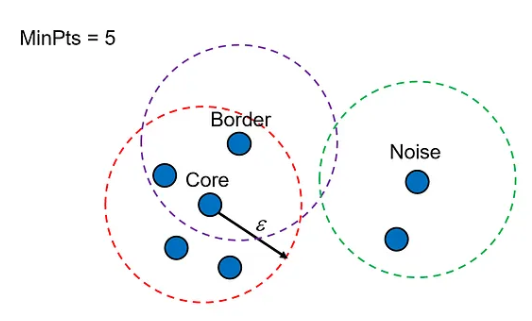

### Step 3: Form Clusters
- Start with an unvisited point:
  1. If it is a **core point**, create a new cluster  
  2. Expand the cluster by adding **all neighbors** within `eps`
- Recursively check neighbors:
  - If neighbor is a core point, add its neighbors too  
  - If neighbor is a border point, add it to the cluster

- Continue until all reachable points from this core point are assigned.


### Step 4: Handle Remaining Points
- Any point that is not assigned to a cluster is labeled as **noise (-1)**.


### Step 5: Output
- Each cluster gets a unique label  
- Noise points are labeled `-1`  

###Result: clusters + noise points

## 2. DBSCAN in Scikit-Learn

### **Most Important Parameters**

#### **1. `epslon`**

Maximum distance between two points for them to be considered neighbors. Controls how close points must be to form clusters

- Smaller `eps` → more points are labeled as **noise**  

- Larger `eps` → clusters may merge, fewer noise points  


#### **2. `min_samples`**

Minimum number of points required to form a **dense region (core point)**. Determines how strict the algorithm is about forming clusters.

**Default:** 5  

- Smaller → clusters form more easily, fewer noise points

- Larger → only dense regions form clusters, more noise points  

**Notes:**  

Often set to **double number of dimension** for small datasets, or higher for noisy data

#### **3. `metric`**
  
Distance metric used to calculate proximity between points. Determines which points are considered “neighbors”

**Default:** `euclidean`

**Common options:**  
  - `euclidean` → straight-line distance; most common for numeric features  
  - `manhattan` → sum of absolute differences; robust to outliers  
  - `cosine` → measures angle between vectors; useful for text embeddings  

**Rule of thumb:**  
Choice of metric affects cluster shape and which points are considered close.  

## Apply DBSCAN to a simple Dataset

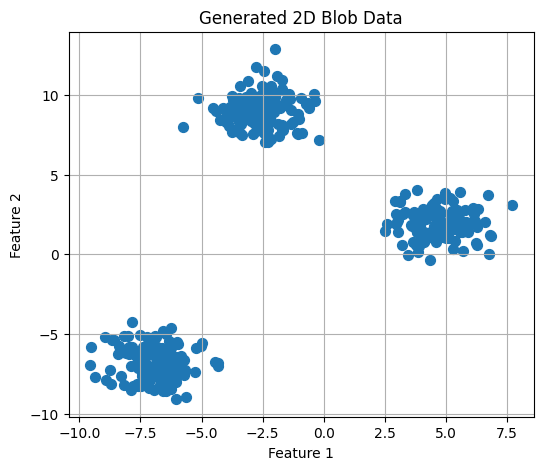

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import seaborn as sns
from sklearn.cluster import DBSCAN


# Generate 2D data: 400 points, 3 centers
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

In [ ]:

# Create DBSCAN model
dbscan = DBSCAN(
    eps=1.2,        # neighborhood radius
    min_samples=5,  # minimum points to form a cluster
    metric='euclidean'
)

# Fit and predict cluster labels
labels = dbscan.fit_predict(X)

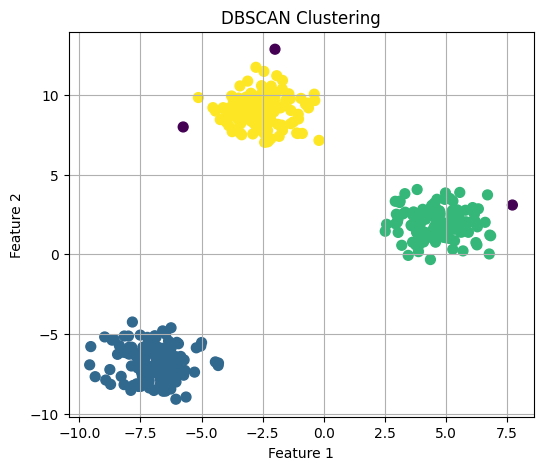

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Compute silhouette score, ignoring noise points
mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
print("Silhouette Score (excluding noise points):", score)

Silhouette Score (excluding noise points): 0.8480963132111413


In [ ]:
outlier_percent = []

for eps in np.linspace(0.001,3,50):

    # Create Model
    dbscan = DBSCAN(eps=eps)
    cluster_labels = dbscan.fit_predict(X)


    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percent.append(perc_outliers)

Text(0.5, 0, 'Epsilon Value')

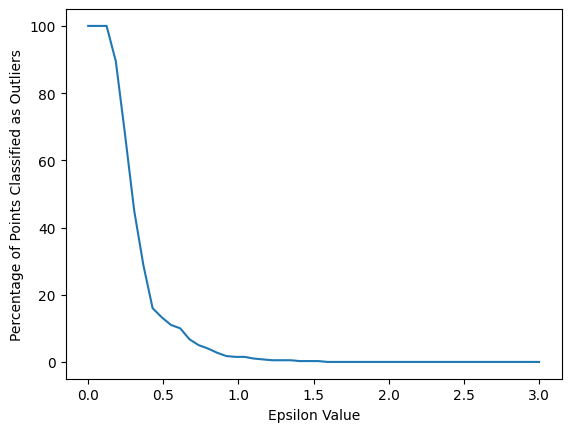

In [ ]:
sns.lineplot(x=np.linspace(0.001,3,50),y=outlier_percent)
plt.ylabel("Percentage of Points Classified as Outliers")
plt.xlabel("Epsilon Value")

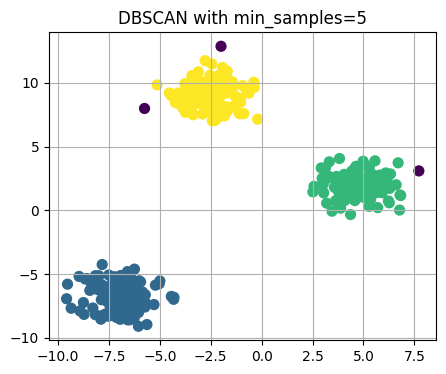

min_samples=5 → Silhouette Score: 0.848


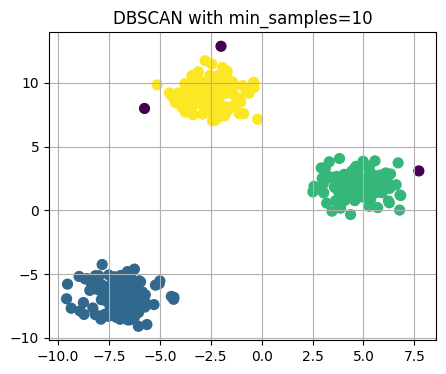

min_samples=10 → Silhouette Score: 0.848


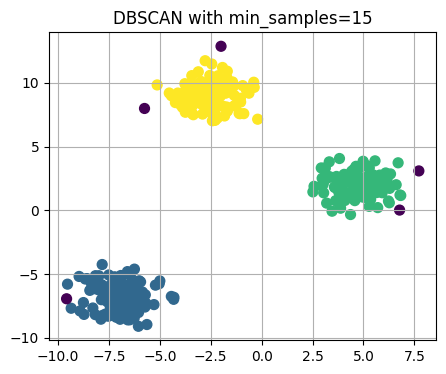

min_samples=15 → Silhouette Score: 0.849


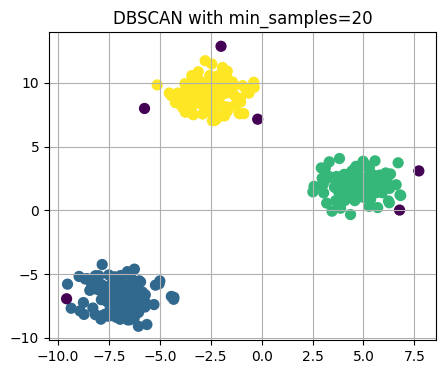

min_samples=20 → Silhouette Score: 0.850


In [ ]:
#Varying min_samples
min_samples_values = [5, 10, 15, 20]

for min_samples in min_samples_values:
    # Apply DBSCAN
    dbscan = DBSCAN(eps=1.2, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    # Visualize clusters
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
    plt.title(f"DBSCAN with min_samples={min_samples}")
    plt.grid(True)
    plt.show()

    # Compute silhouette score (ignore noise)
    mask = labels != -1  # exclude noise
    if len(set(labels[mask])) > 1:  # silhouette score requires >=2 clusters
        score = silhouette_score(X[mask], labels[mask])
        print(f"min_samples={min_samples} → Silhouette Score: {score:.3f}")
    else:
        print(f"min_samples={min_samples} → Too few clusters to compute silhouette score")

## Task 2B: DBSCAN

Dataset: `CC GENERAL.csv`  
Goal: Use **DBSCAN** to find clusters of customers and identify potential outliers.


## 1. Exploratory Data Analysis (EDA)



## Check Missing Values (EDA)

### Subtask:
Calculate and display the count and percentage of missing values for each column in the DataFrame.


**Reasoning**:
First, I'll calculate the sum of missing values for each column and then their respective percentages. Afterwards, I will create a new DataFrame `missing_info` to store this information and then display it to fulfill the subtask requirements.



In [5]:
missing_values = df.isnull().sum()
percentage_missing = 100 * df.isnull().sum() / len(df)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': percentage_missing
})

print("Missing Values Information:")
print(missing_info)


Missing Values Information:
                                  Missing Count  Percentage
CUST_ID                                       0         0.0
BALANCE                                       0         0.0
BALANCE_FREQUENCY                             0         0.0
PURCHASES                                     0         0.0
ONEOFF_PURCHASES                              0         0.0
INSTALLMENTS_PURCHASES                        0         0.0
CASH_ADVANCE                                  0         0.0
PURCHASES_FREQUENCY                           0         0.0
ONEOFF_PURCHASES_FREQUENCY                    0         0.0
PURCHASES_INSTALLMENTS_FREQUENCY              0         0.0
CASH_ADVANCE_FREQUENCY                        0         0.0
CASH_ADVANCE_TRX                              0         0.0
PURCHASES_TRX                                 0         0.0
CREDIT_LIMIT                                  0         0.0
PAYMENTS                                      0         0.0
MINIMUM_PAYM

## Final Task

### Subtask:
Confirm that the missing value check for EDA is complete.


## Summary:

### Q&A
The missing value check for EDA is complete.

### Data Analysis Key Findings
*   All columns in the DataFrame (`CUST_ID`, `BALANCE`, `BALANCE_FREQUENCY`, `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `PURCHASES_FREQUENCY`, `ONEOFF_PURCHASES_FREQUENCY`, `PURCHASES_INSTALLMENTS_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, `PURCHASES_TRX`, `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT`, `TENURE`) have zero missing values.
*   The percentage of missing data across all columns is 0.0%.

### Insights or Next Steps
*   Since there are no missing values, no imputation or missing data handling steps are required, which simplifies the data preprocessing phase.
*   Proceed with further exploratory data analysis, such as outlier detection, distribution analysis, and correlation analysis.


## 2. Data Preparation

# Task
**Task**: Prepare the `df` DataFrame for DBSCAN clustering by dropping the 'CUST_ID' column and scaling the remaining features using `StandardScaler`. The step for imputing missing values in 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS' will be skipped as the `df` DataFrame currently contains no missing values in these columns, as confirmed by the previous missing value check.

## Handle Missing Values

### Subtask:
Impute missing values in 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS' columns using the median.


**Reasoning**:
To confirm that no imputation is required for 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS' as stated in the instructions, I will first verify that these columns indeed have no missing values by displaying the sum of nulls for these specific columns.



In [6]:
print(df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].isnull().sum())

CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64


The verification in the previous step shows that both `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` columns have 0 missing values. Therefore, no imputation is required for these columns. The subtask is complete.

## Drop Customer ID

### Subtask:
Remove the 'CUST_ID' column as it is not relevant for clustering.


**Reasoning**:
To remove the 'CUST_ID' column, I will use the `drop()` method on the `df` DataFrame, specifying `axis=1` for columns and `inplace=True` to modify the DataFrame directly.



In [7]:
df.drop('CUST_ID', axis=1, inplace=True)
print(" 'CUST_ID' column dropped successfully.")

 'CUST_ID' column dropped successfully.


## Scale Features

### Subtask:
Scale all remaining numerical features in the `df` DataFrame using `StandardScaler`.

## Scale Features

### Subtask:
Scale all remaining numerical features in the `df` DataFrame using `StandardScaler`.

## Scale Features

### Subtask:
Scale all remaining numerical features in the `df` DataFrame using `StandardScaler`.

**Reasoning**:
To scale the numerical features, I will first import `StandardScaler`, initialize it, and then apply it to the `df` DataFrame. The scaled data will be stored in a new DataFrame `df_scaled`.



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Features scaled successfully. The shape of the scaled data is:", df_scaled.shape)

Features scaled successfully. The shape of the scaled data is: (8950, 17)


## Final Task

### Subtask:
Confirm that the data preparation steps are complete and the data is ready for DBSCAN.


## Summary:

### Data Analysis Key Findings

*   The `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` columns were confirmed to have no missing values, therefore no imputation was required for these columns.
*   The `CUST_ID` column was successfully dropped from the DataFrame as it is not relevant for clustering analysis.
*   All remaining numerical features in the DataFrame were successfully scaled using `StandardScaler`. The resulting scaled data, `df_scaled`, has a shape of (8950, 17), indicating 8950 samples and 17 features.

### Insights or Next Steps

*   The data has been successfully prepared and is now ready for DBSCAN clustering, as all irrelevant identifiers have been removed and features have been scaled appropriately.
*   Proceed with applying the DBSCAN algorithm to the `df_scaled` data to identify clusters.


## 3. Apply DBSCAN




# Task
Apply DBSCAN with `eps=0.5` and `min_samples=10` to `df_scaled`, then use PCA to reduce `df_scaled` to 2 components and visualize the DBSCAN clusters.

## Apply DBSCAN (Initial Run)

### Subtask:
Initialize and apply the DBSCAN algorithm with initial parameters (e.g., `eps=0.5`, `min_samples=10`) to the scaled data. Predict the cluster labels.


**Reasoning**:
To apply the DBSCAN algorithm, I need to import the `DBSCAN` class, initialize it with the specified parameters, and then fit and predict the cluster labels on the `df_scaled` data.



In [9]:
from sklearn.cluster import DBSCAN

# Initialize DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=10)

# Fit the model and predict cluster labels
dbscan_labels = dbscan.fit_predict(df_scaled)

print("DBSCAN clustering applied and labels predicted.")

DBSCAN clustering applied and labels predicted.


**Reasoning**:
The previous step successfully applied DBSCAN. Now, to visualize these clusters, I need to reduce the dimensionality of the `df_scaled` data to 2 principal components using PCA, as per the main task's instructions. This will allow for 2D plotting.



In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
pca_2d = pca.fit_transform(df_scaled)

print("Data dimensionality reduced to 2D using PCA.")

Data dimensionality reduced to 2D using PCA.


**Reasoning**:
To visualize the DBSCAN clusters, I will plot the 2D PCA transformed data, coloring the points based on the `dbscan_labels` previously generated. This will visually represent the clusters found by DBSCAN.



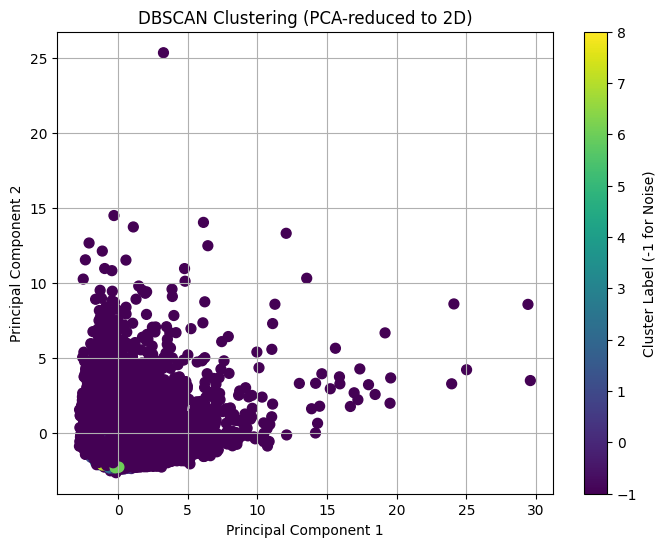

DBSCAN clusters visualized using PCA-reduced data.


In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title('DBSCAN Clustering (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label (-1 for Noise)')
plt.grid(True)
plt.show()

print("DBSCAN clusters visualized using PCA-reduced data.")

## Evaluate Initial DBSCAN Clustering

### Subtask:
Analyze the number of clusters and noise points, and calculate the silhouette score for the initial DBSCAN run.


**Reasoning**:
To analyze the initial DBSCAN clustering, I will first calculate the number of unique clusters and the count and percentage of noise points from `dbscan_labels`. Then, I will compute the silhouette score for the clustered data, ensuring to exclude noise points and handle cases where silhouette score calculation is not feasible due to too few clusters or data points. Finally, I will print all these metrics as requested.



In [12]:
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Determine the number of unique clusters
unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# 2. Count noise points
noise_points = np.sum(dbscan_labels == -1)

# 3. Calculate the percentage of noise points
total_samples = len(df_scaled)
percentage_noise = (noise_points / total_samples) * 100

print(f"Number of clusters found: {unique_clusters}")
print(f"Number of noise points: {noise_points}")
print(f"Percentage of noise points: {percentage_noise:.2f}%")

# 4. Compute the silhouette score
# Create a mask to exclude noise points
non_noise_mask = dbscan_labels != -1

# Filter df_scaled and dbscan_labels for silhouette score calculation
clustered_data = df_scaled[non_noise_mask]
filtered_labels = dbscan_labels[non_noise_mask]

# Check if there are at least two clusters and enough samples for silhouette score
if unique_clusters >= 2 and len(clustered_data) > 1:
    silhouette_avg = silhouette_score(clustered_data, filtered_labels)
    print(f"Silhouette Score (excluding noise points): {silhouette_avg:.3f}")
else:
    print("Cannot compute Silhouette Score: Not enough clusters or data points (excluding noise) found.")

Number of clusters found: 9
Number of noise points: 7188
Percentage of noise points: 80.31%
Silhouette Score (excluding noise points): -0.155


## Summary:

### Q&A
*   **How many clusters were found with the initial DBSCAN parameters (`eps=0.5`, `min_samples=10`)?**
    9 clusters were found.
*   **How many noise points were identified, and what percentage do they represent?**
    7188 noise points were identified, representing 80.31% of the total samples.
*   **What was the Silhouette Score for the initial DBSCAN clustering (excluding noise points)?**
    The Silhouette Score was -0.155.

### Data Analysis Key Findings
*   DBSCAN with `eps=0.5` and `min_samples=10` was successfully applied to the scaled data (`df_scaled`), and PCA reduced the dimensionality to 2 components for visualization.
*   The initial DBSCAN run identified 9 unique clusters.
*   A substantial portion of the data, 7188 points (80.31% of total samples), was classified as noise.
*   The Silhouette Score of -0.155 (calculated excluding noise points) indicates poor clustering, suggesting that data points in clusters are, on average, closer to neighboring clusters than to their own.

### Insights or Next Steps
*   The current DBSCAN parameters (`eps=0.5`, `min_samples=10`) are suboptimal, as evidenced by the high percentage of noise points and the negative Silhouette Score. Further parameter tuning is necessary to achieve a more meaningful clustering.
*   Experiment with different values for `eps` and `min_samples` to reduce noise and improve cluster separation, aiming for a higher (positive) Silhouette Score.


## 4. Evaluate the Clustering

# Task
Analyze the impact of varying `eps` values on the percentage of outliers in the DBSCAN clustering of the customer dataset.

## Analyze Outlier Percentage (eps)

### Subtask:
Loop through a range of `eps` values and for each `eps`, apply DBSCAN and calculate the percentage of points classified as outliers. Plot these percentages against the `eps` values to observe the impact of `eps` on noise identification.


**Reasoning**:
I will create an empty list for outlier percentages, define the range of `eps` values, and then loop through them. Inside the loop, I'll apply DBSCAN, calculate the percentage of outliers, and store it. Finally, I will generate a line plot to visualize the results, as instructed.



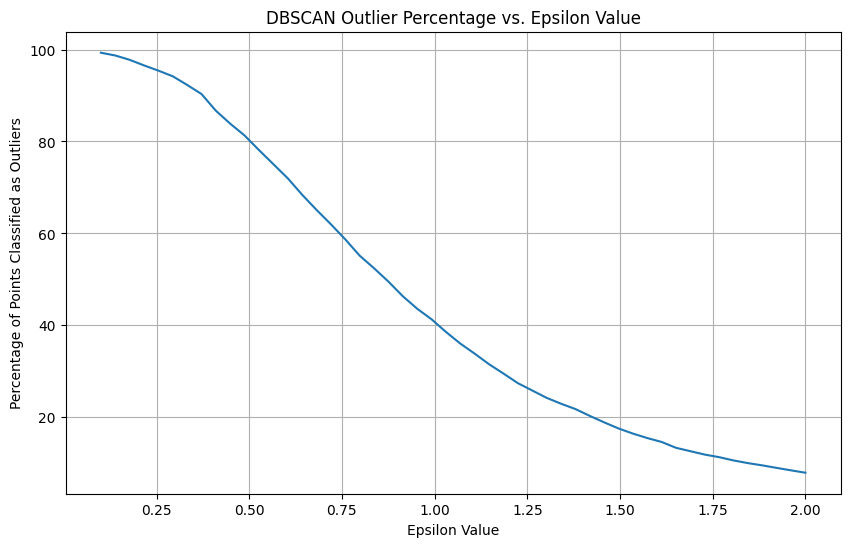

DBSCAN outlier percentage analysis for varying epsilon values completed and plotted.


In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

outlier_percentages = []
eps_values = np.linspace(0.1, 2.0, 50)

for eps in eps_values:
    # Create Model
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10 # Using the same min_samples as the initial run
    )
    cluster_labels = dbscan.fit_predict(df_scaled)

    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percentages.append(perc_outliers)

plt.figure(figsize=(10, 6))
sns.lineplot(x=eps_values, y=outlier_percentages)
plt.title('DBSCAN Outlier Percentage vs. Epsilon Value')
plt.ylabel('Percentage of Points Classified as Outliers')
plt.xlabel('Epsilon Value')
plt.grid(True)
plt.show()

print("DBSCAN outlier percentage analysis for varying epsilon values completed and plotted.")

## Analyze Outlier Percentage (min_samples)

### Subtask:
Loop through a range of `min_samples` values and for each `min_samples`, apply DBSCAN with a fixed `eps` (e.g., the optimal `eps` found in the previous step or a reasonable default like 0.5) and calculate the percentage of points classified as outliers. Plot these percentages against the `min_samples` values to observe the impact of `min_samples` on noise identification.


**Reasoning**:
To analyze the impact of `min_samples` on outlier identification, I will loop through a range of `min_samples` values, apply DBSCAN with a fixed `eps` (0.5), calculate the percentage of outliers for each `min_samples` value, and then visualize these percentages in a line plot.



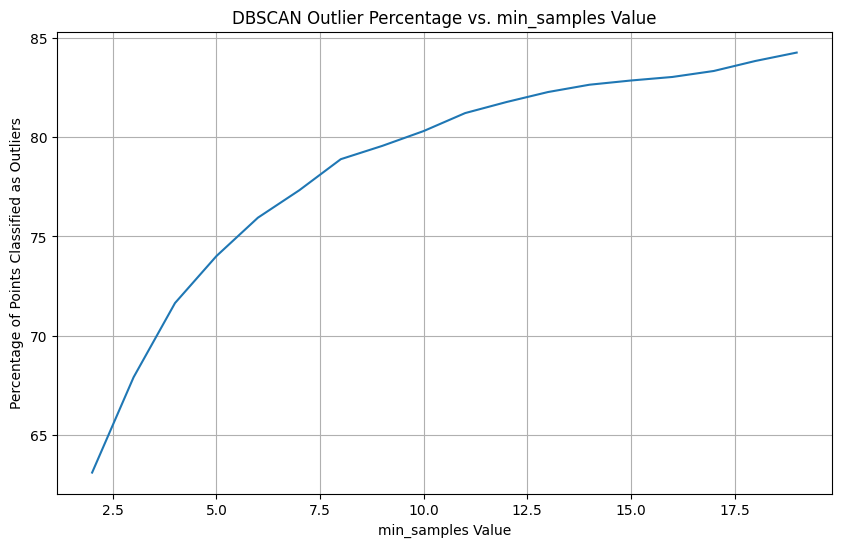

DBSCAN outlier percentage analysis for varying min_samples values completed and plotted.


In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

outlier_percentages_min_samples = []
min_samples_values = np.arange(2, 20, 1)

# Using a fixed eps value, e.g., 0.5 as used in the initial run
fixed_eps = 0.5

for min_samples in min_samples_values:
    # Create Model
    dbscan = DBSCAN(
        eps=fixed_eps,
        min_samples=min_samples
    )
    cluster_labels = dbscan.fit_predict(df_scaled)

    # Log percentage of points that are outliers
    perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(cluster_labels)

    outlier_percentages_min_samples.append(perc_outliers)

plt.figure(figsize=(10, 6))
sns.lineplot(x=min_samples_values, y=outlier_percentages_min_samples)
plt.title('DBSCAN Outlier Percentage vs. min_samples Value')
plt.ylabel('Percentage of Points Classified as Outliers')
plt.xlabel('min_samples Value')
plt.grid(True)
plt.show()

print("DBSCAN outlier percentage analysis for varying min_samples values completed and plotted.")

## Iterate and Visualize with Varying min_samples

### Subtask:
Apply DBSCAN using various `min_samples` values (e.g., 5, 10, 20) while keeping `eps` fixed. For each `min_samples` value, visualize the clusters using PCA for dimensionality reduction and compute the silhouette score (excluding noise points). This will help in understanding how `min_samples` affects the formation and quality of clusters.


**Reasoning**:
I will define the list of `min_samples` values, set a fixed `eps`, and then loop through each `min_samples` value. Inside the loop, I will apply DBSCAN, visualize the clusters using PCA-reduced data, and calculate the silhouette score, ensuring to handle cases where the score cannot be computed.




--- Running DBSCAN with min_samples=5, eps=0.5 ---
Number of clusters found: 36
Number of noise points: 6624
Percentage of noise points: 74.01%


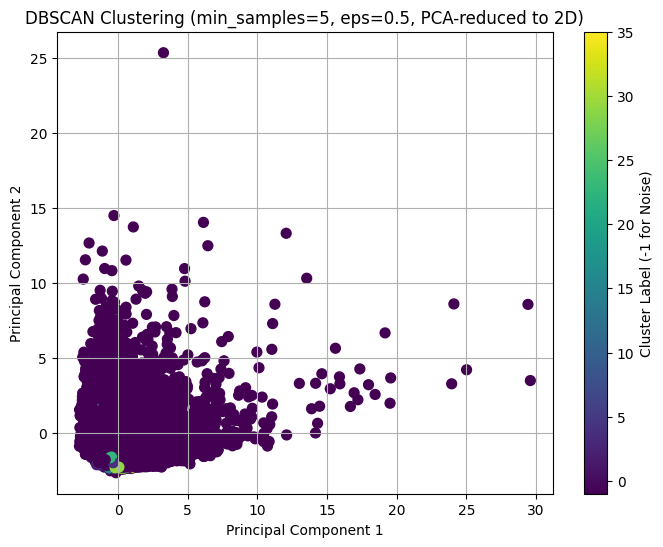

Silhouette Score (excluding noise points): -0.376

--- Running DBSCAN with min_samples=10, eps=0.5 ---
Number of clusters found: 9
Number of noise points: 7188
Percentage of noise points: 80.31%


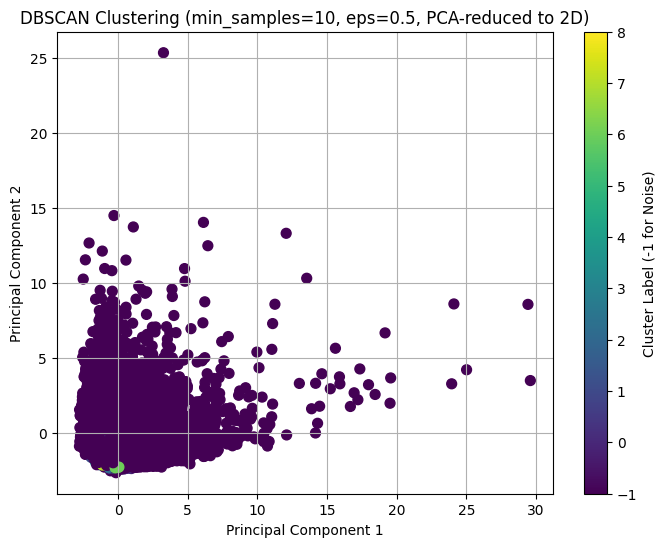

Silhouette Score (excluding noise points): -0.155

--- Running DBSCAN with min_samples=20, eps=0.5 ---
Number of clusters found: 6
Number of noise points: 7594
Percentage of noise points: 84.85%


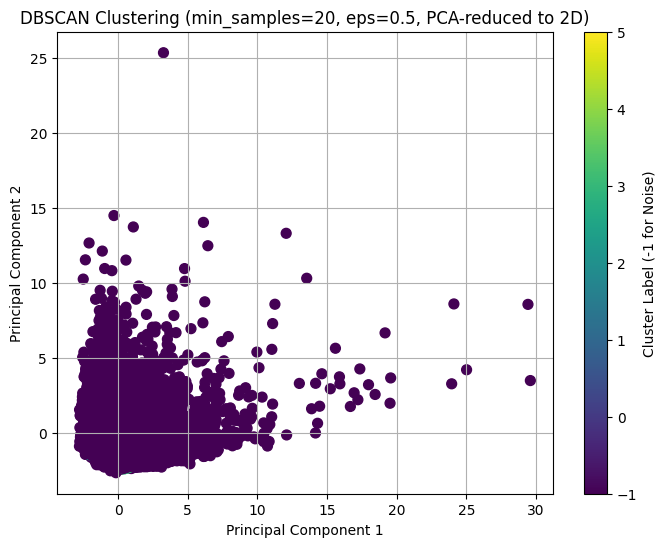

Silhouette Score (excluding noise points): 0.373


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Define min_samples values to iterate through
min_samples_values = [5, 10, 20]

# 2. Set a fixed eps value
fixed_eps = 0.5

# Ensure PCA has been performed and pca_2d is available
# If not, perform it here (assuming df_scaled is available from previous steps)
if 'pca_2d' not in locals():
    pca = PCA(n_components=2)
    pca_2d = pca.fit_transform(df_scaled)

for min_samples in min_samples_values:
    print(f"\n--- Running DBSCAN with min_samples={min_samples}, eps={fixed_eps} ---")

    # a. Initialize and apply DBSCAN
    dbscan = DBSCAN(
        eps=fixed_eps,
        min_samples=min_samples
    )
    dbscan_labels = dbscan.fit_predict(df_scaled)

    # Count unique clusters (excluding noise)
    unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    noise_points = np.sum(dbscan_labels == -1)
    percentage_noise = (noise_points / len(df_scaled)) * 100

    print(f"Number of clusters found: {unique_clusters}")
    print(f"Number of noise points: {noise_points}")
    print(f"Percentage of noise points: {percentage_noise:.2f}%")

    # c, d, e, f. Visualize the clusters
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=dbscan_labels, cmap='viridis', s=50)
    plt.title(f'DBSCAN Clustering (min_samples={min_samples}, eps={fixed_eps}, PCA-reduced to 2D)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(scatter, label='Cluster Label (-1 for Noise)')
    plt.grid(True)
    plt.show()

    # g. Filter out noise points
    non_noise_mask = dbscan_labels != -1
    clustered_data = df_scaled[non_noise_mask]
    filtered_labels = dbscan_labels[non_noise_mask]

    # h, i. Calculate and print the silhouette score
    if unique_clusters >= 2 and len(clustered_data) > 1:
        silhouette_avg = silhouette_score(clustered_data, filtered_labels)
        print(f"Silhouette Score (excluding noise points): {silhouette_avg:.3f}")
    else:
        print("Cannot compute Silhouette Score: Not enough clusters or data points (excluding noise) found.")


## Final Task

### Subtask:
Summarize the findings from the DBSCAN analysis on the customer dataset, including insights into the identified clusters, the proportion of outliers, and the impact of the `eps` and `min_samples` parameters on the clustering results and silhouette score.


## Summary:

### Data Analysis Key Findings

*   **Impact of `eps` on Outlier Percentage**: As the `eps` (epsilon) value increased, the percentage of points classified as outliers generally decreased. This indicates that a larger `eps` allows points to be considered neighbors from a greater distance, leading to more points being included in clusters and fewer being labeled as noise.
*   **Impact of `min_samples` on Outlier Percentage (fixed `eps`)**: As the `min_samples` value increased while `eps` was fixed, the percentage of points classified as outliers generally increased. This suggests that a higher `min_samples` requires more neighboring points to form a core point, thus making it more difficult for isolated points or small groups to form clusters, thereby increasing the number of noise points.
*   **Detailed Analysis for Varying `min_samples` (with `eps` = 0.5):**
    *   **`min_samples` = 5**: Resulted in 36 clusters, 74.01% noise, and a silhouette score of -0.376.
    *   **`min_samples` = 10**: Resulted in 9 clusters, 80.31% noise, and a silhouette score of -0.155.
    *   **`min_samples` = 20**: Resulted in 6 clusters, 84.85% noise, and a silhouette score of 0.373.
*   **Trade-offs with `min_samples`**: Increasing `min_samples` led to fewer but generally better-defined clusters (as indicated by the improving silhouette score), but at the cost of classifying a significantly higher percentage of data points as noise.

### Insights or Next Steps

*   **Parameter Sensitivity**: The analysis clearly demonstrates the high sensitivity of DBSCAN's clustering results (number of clusters, outlier percentage, and cluster quality) to the `eps` and `min_samples` parameters. Careful tuning is crucial for meaningful outcomes.
*   **Optimal Parameter Selection**: For the given dataset, an `min_samples` value of 20 with `eps` = 0.5 yielded a positive silhouette score of 0.373, suggesting reasonably well-separated clusters, despite a high percentage of noise. Future steps could involve finding the optimal balance between cluster quality (silhouette score) and the acceptable proportion of noise by systematically exploring the parameter space of `eps` and `min_samples` together.
